In [69]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Load cleaned data
df = pd.read_csv("cleaned_employee_data.csv")

# Split into features and target
X = df[['OverTime', 'JobSatisfaction', 'Age']]
y = df['Attrition']

# Scale data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split (70/30)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

In [71]:
# Create and train model
model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)

In [73]:
# Evaluation
print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print(f"Precision: {precision_score(y_test, y_pred) * 100:.2f}%")
print(f"Recall: {recall_score(y_test, y_pred) * 100:.2f}%")
print(f"F1 Score: {f1_score(y_test, y_pred) * 100:.2f}%")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 85.49%
Precision: 20.00%
Recall: 1.64%
F1 Score: 3.03%

Confusion Matrix:
 [[376   4]
 [ 60   1]]

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.99      0.92       380
           1       0.20      0.02      0.03        61

    accuracy                           0.85       441
   macro avg       0.53      0.50      0.48       441
weighted avg       0.77      0.85      0.80       441



In [75]:
# Show coefficients with feature names
# Top 3 features positively correlated with Attrition
coefficients = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_[0]})
coefficients = coefficients.sort_values(by='Coefficient', ascending=False)
print(coefficients.head(10))

           Feature  Coefficient
0         OverTime     0.676580
1  JobSatisfaction    -0.311690
2              Age    -0.546662


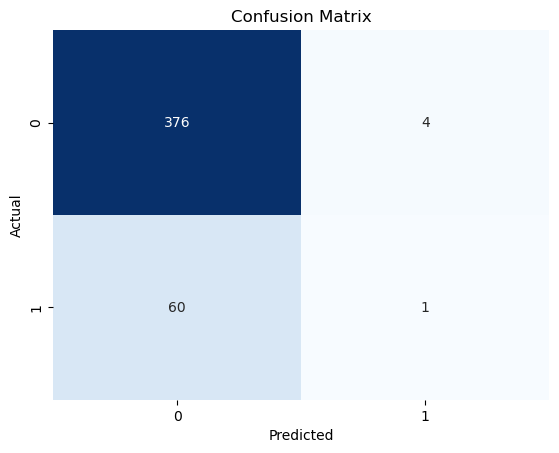

In [77]:
from sklearn.metrics import ConfusionMatrixDisplay

# Plot Confusion Matrix Heatmap
def plot_conf_matrix(y_test, y_pred, title="Confusion Matrix"):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


# For Logistic Regression
plot_conf_matrix(y_test, y_pred)

In [79]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print(f"True Positives: {tp}")
print(f"True Negatives: {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")

True Positives: 1
True Negatives: 376
False Positives: 4
False Negatives: 60


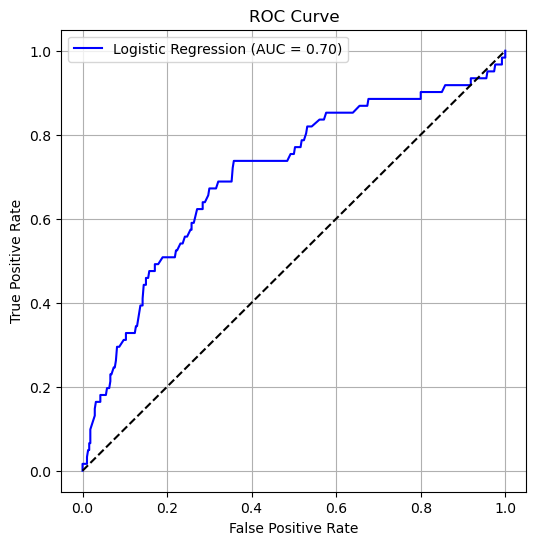

In [81]:
from sklearn.metrics import roc_curve, roc_auc_score

# Get predicted probabilities
y_probs = model.predict_proba(X_test)[:, 1]  # Probabilities for class 1

# Compute ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc = roc_auc_score(y_test, y_probs)

# Plot
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc:.2f})", color='blue')
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line = random guessing
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid()
plt.show()


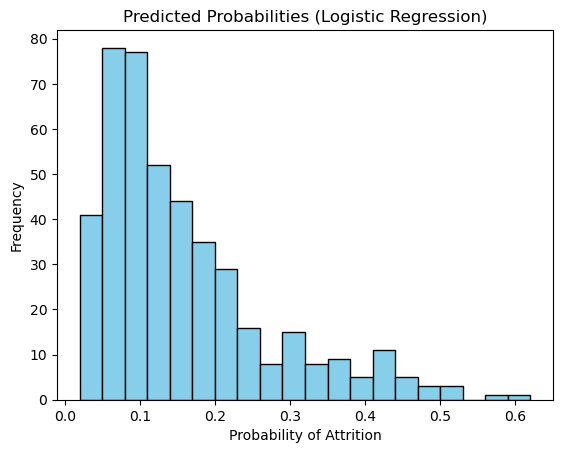

In [83]:
probs = model.predict_proba(X_test)[:, 1]
plt.hist(probs, bins=20, color='skyblue', edgecolor='black')
plt.title('Predicted Probabilities (Logistic Regression)')
plt.xlabel('Probability of Attrition')
plt.ylabel('Frequency')
plt.show()